In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import plotly.express as px

from sklearn.model_selection import train_test_split

from sklearn.impute import SimpleImputer

from sklearn.preprocessing import LabelEncoder

from sklearn.pipeline import Pipeline

from sklearn.compose import ColumnTransformer

from sklearn.metrics import *

from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.linear_model import LogisticRegression

In [2]:
df=pd.read_parquet("data_0.parquet")

df.head()

,report_date,client_hash_id,content_hash_id,client_has_gsc,client_has_ga4,gsc_data_available,ga4_data_available,gsc_impressions,gsc_clicks,gsc_sum_position,...,sessions_paid,sessions_ai,ai_chatgpt,ai_perplexity,ai_gemini,ai_copilot,ai_claude,ai_meta,ai_other,scroll_events
0,2025-01-27,client_9958f0a7ae1df715,content_3b70a18ea133b2bb,True,True,True,False,30,0,115,...,0,0,0,0,0,0,0,0,0,0
1,2025-01-27,client_9958f0a7ae1df715,content_fe8e8155ce1d47a2,True,True,True,False,5,0,358,...,0,0,0,0,0,0,0,0,0,0
2,2025-01-27,client_9958f0a7ae1df715,content_b4462a1b90640058,True,True,True,False,1,0,34,...,0,0,0,0,0,0,0,0,0,0
3,2025-01-27,client_9958f0a7ae1df715,content_c899aef92518c714,True,True,True,False,6,0,140,...,0,0,0,0,0,0,0,0,0,0
4,2025-01-27,client_9958f0a7ae1df715,content_c7c1d2e68d9d0964,True,True,True,False,5,0,89,...,0,0,0,0,0,0,0,0,0,0


In [3]:
df.describe(include="all")

,report_date,client_hash_id,content_hash_id,client_has_gsc,client_has_ga4,gsc_data_available,ga4_data_available,gsc_impressions,gsc_clicks,gsc_sum_position,...,sessions_paid,sessions_ai,ai_chatgpt,ai_perplexity,ai_gemini,ai_copilot,ai_claude,ai_meta,ai_other,scroll_events
count,1297,1297,1297,1297,1297,1297,1297,1297.000000,1297.000000,1297.000000,...,1297.0,1297.0,1297.0,1297.0,1297.0,1297.0,1297.0,1297.0,1297.0,1297.0
unique,5,2,476,1,1,1,1,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,2025-01-28,client_9958f0a7ae1df715,content_1cbb5d72fbabe49a,True,True,True,False,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,317,770,5,1297,1297,1297,1297,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.680802,0.083269,275.527371,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,22.076848,0.429440,466.358262,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.000000,0.000000,48.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.000000,0.000000,110.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.000000,0.000000,278.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [4]:
missing=df.isnull().sum()

missing=missing[missing>0]

missing.sort_values(ascending=False)

,0


In [5]:
(df.isnull().mean()*100).sort_values(ascending=False)

,0
report_date,0.0
client_hash_id,0.0
content_hash_id,0.0
client_has_gsc,0.0
client_has_ga4,0.0
gsc_data_available,0.0
ga4_data_available,0.0
gsc_impressions,0.0
gsc_clicks,0.0
gsc_sum_position,0.0


In [7]:
df=df.drop_duplicates()

In [8]:
df.columns

Index(['report_date', 'client_hash_id', 'content_hash_id', 'client_has_gsc',
       'client_has_ga4', 'gsc_data_available', 'ga4_data_available',
       'gsc_impressions', 'gsc_clicks', 'gsc_sum_position', 'gsc_avg_position',
       'ga4_pageviews', 'ga4_sessions', 'ga4_users', 'ga4_engaged_sessions',
       'ga4_total_engagement_sec', 'sessions_organic', 'sessions_direct',
       'sessions_referral', 'sessions_social', 'sessions_paid', 'sessions_ai',
       'ai_chatgpt', 'ai_perplexity', 'ai_gemini', 'ai_copilot', 'ai_claude',
       'ai_meta', 'ai_other', 'scroll_events'],
      dtype='object')

In [9]:
num=df.select_dtypes(include=np.number)

num.columns

Index(['gsc_impressions', 'gsc_clicks', 'gsc_sum_position', 'gsc_avg_position',
       'ga4_pageviews', 'ga4_sessions', 'ga4_users', 'ga4_engaged_sessions',
       'ga4_total_engagement_sec', 'sessions_organic', 'sessions_direct',
       'sessions_referral', 'sessions_social', 'sessions_paid', 'sessions_ai',
       'ai_chatgpt', 'ai_perplexity', 'ai_gemini', 'ai_copilot', 'ai_claude',
       'ai_meta', 'ai_other', 'scroll_events'],
      dtype='object')

In [10]:
cat=df.select_dtypes(exclude=np.number)

cat.columns

Index(['report_date', 'client_hash_id', 'content_hash_id', 'client_has_gsc',
       'client_has_ga4', 'gsc_data_available', 'ga4_data_available'],
      dtype='object')

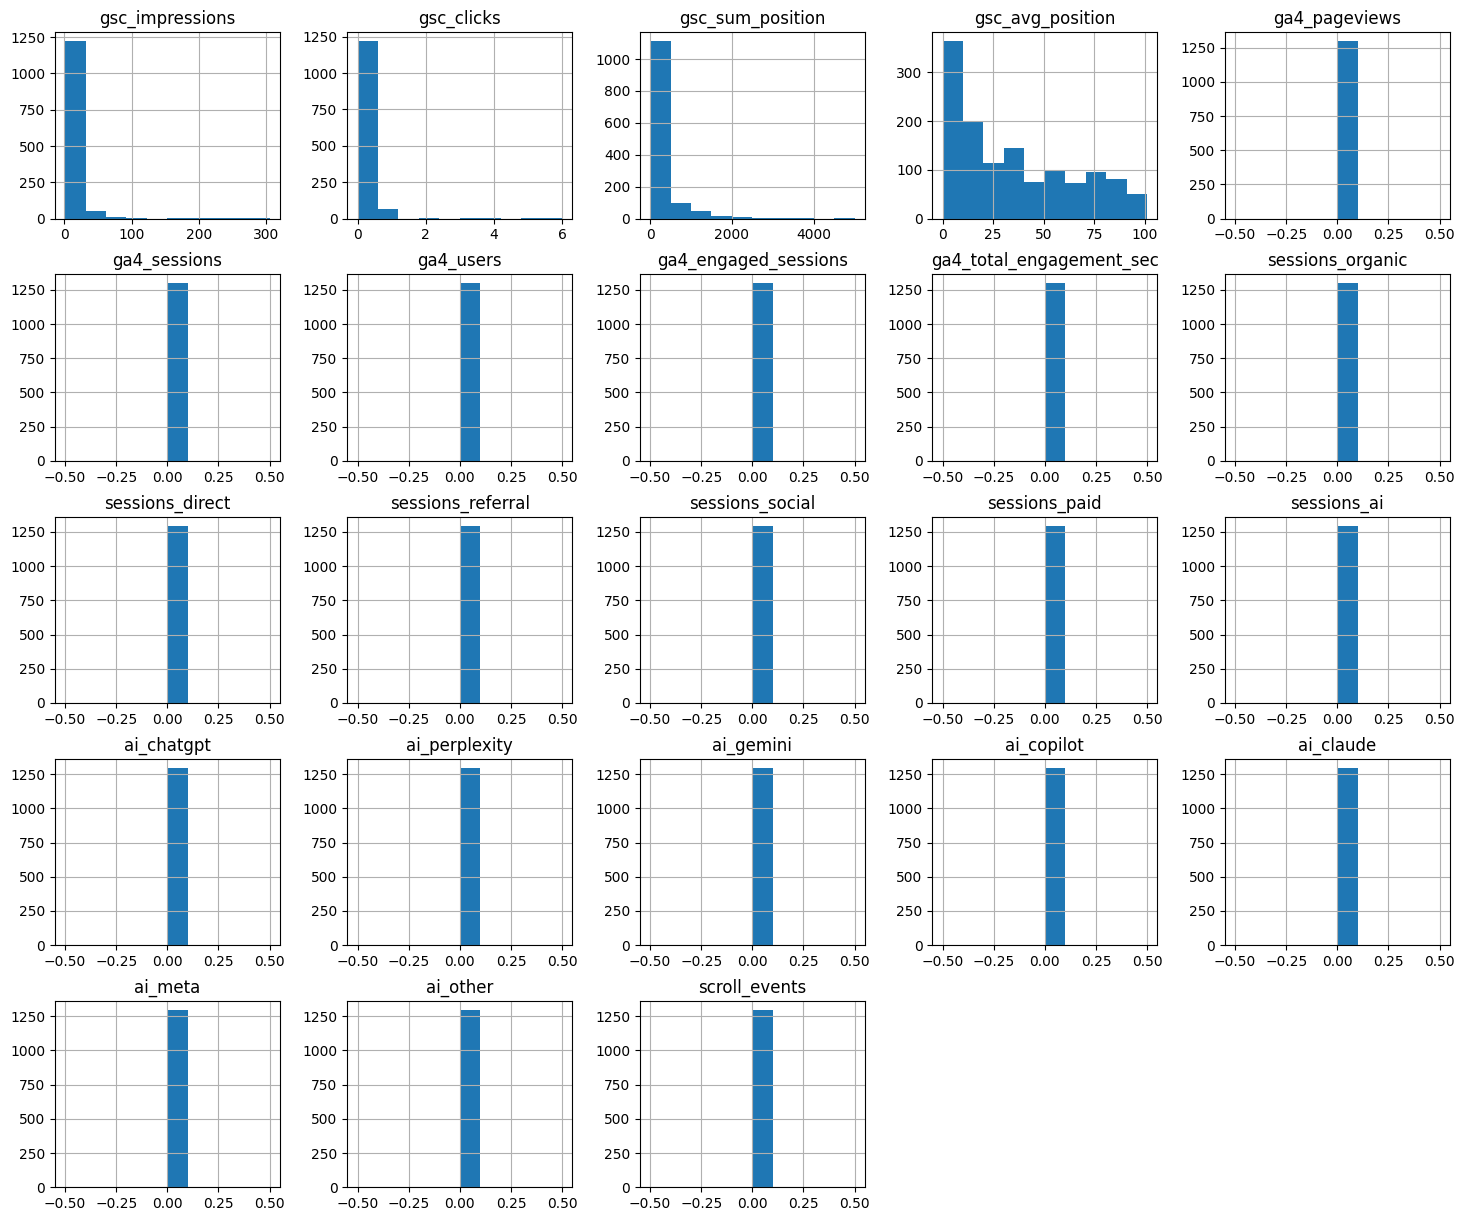

In [11]:
num.hist(figsize=(18,15))
plt.show()

<Axes: >

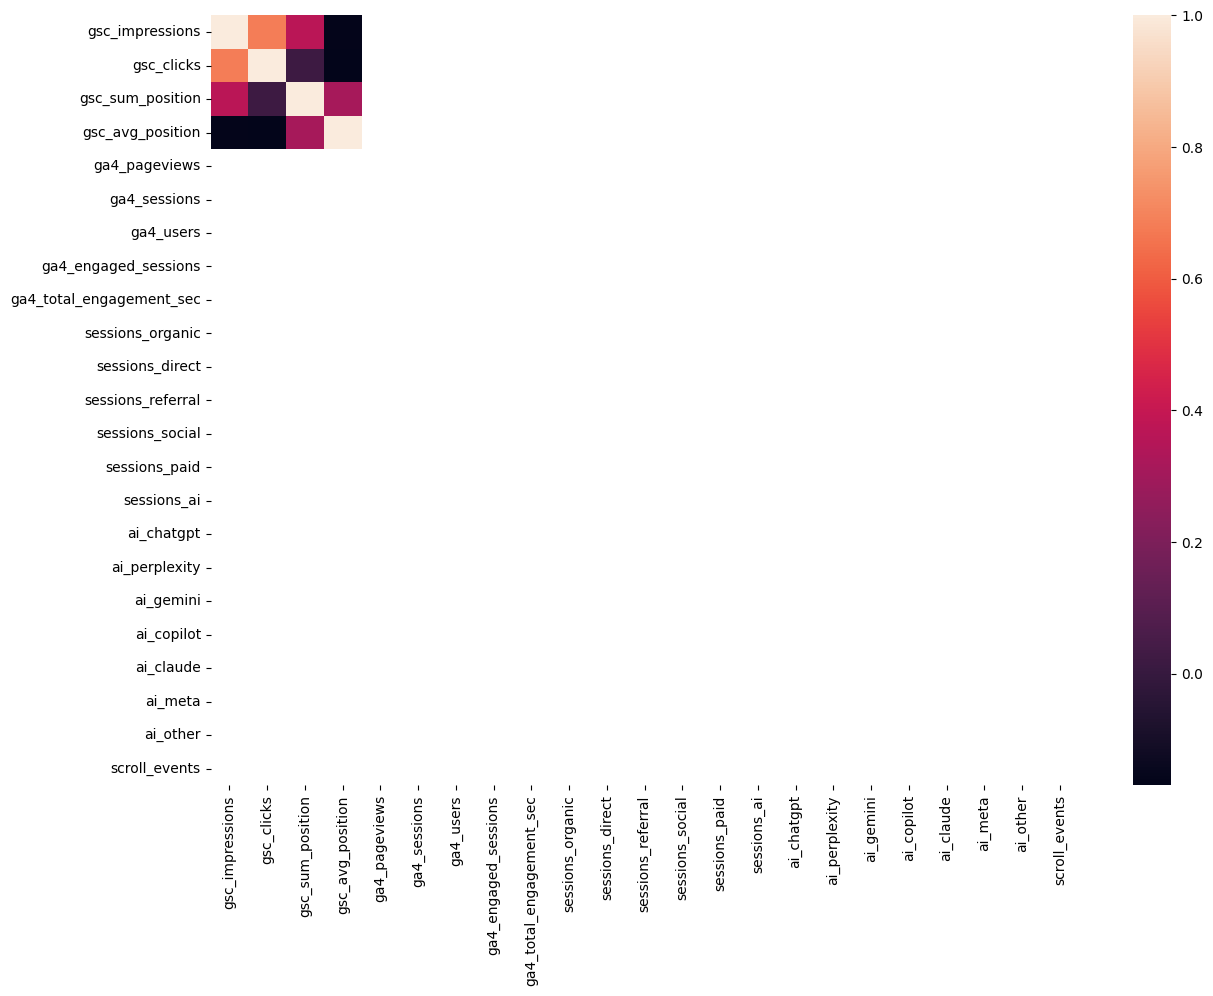

In [12]:
corr=num.corr()

plt.figure(figsize=(14,10))

import seaborn as sns

sns.heatmap(corr)

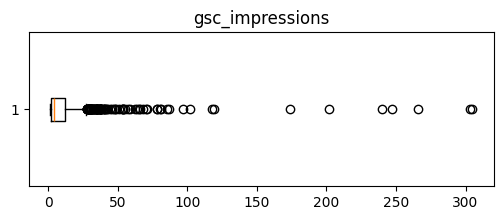

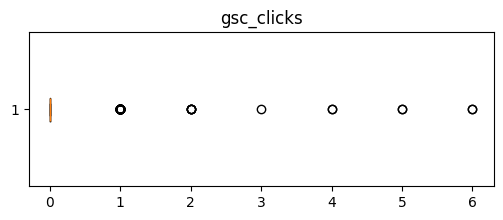

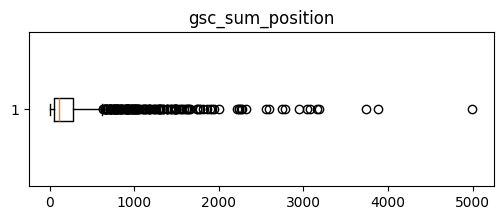

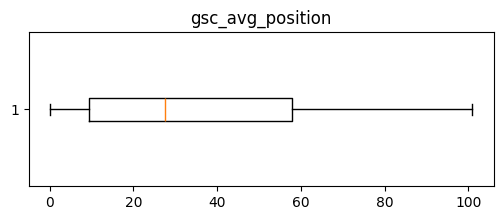

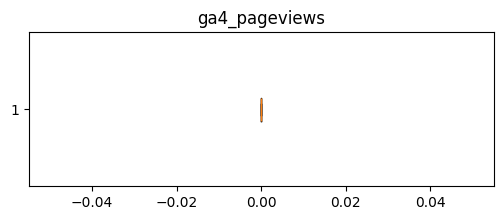

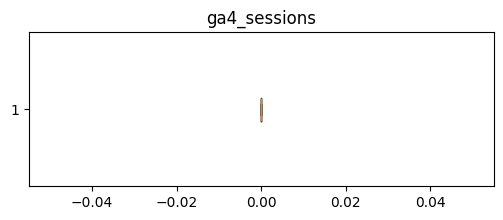

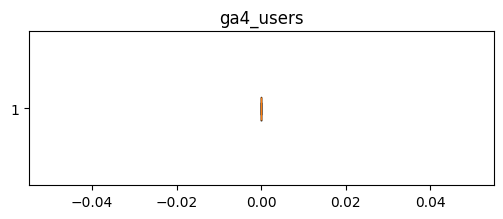

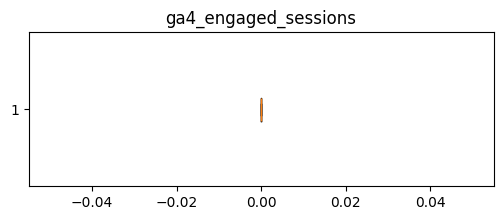

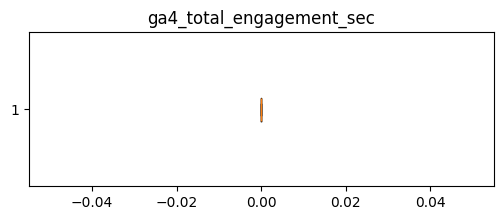

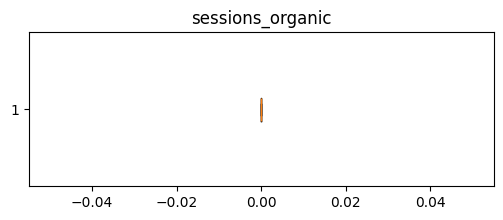

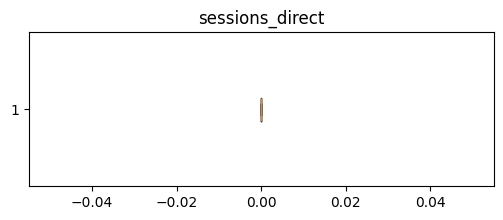

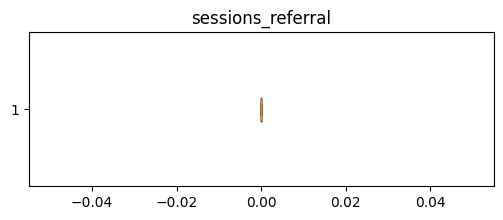

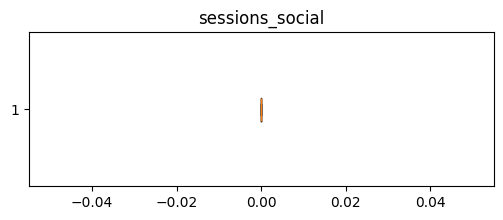

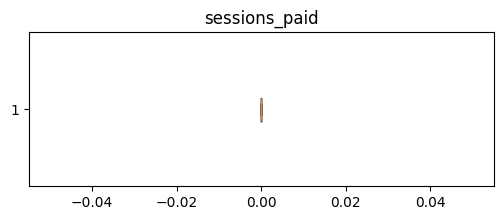

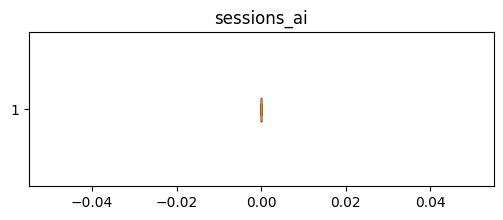

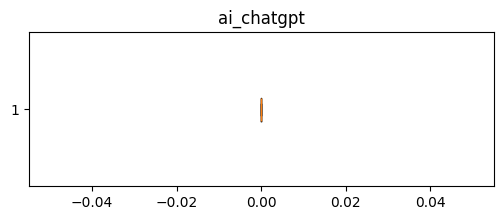

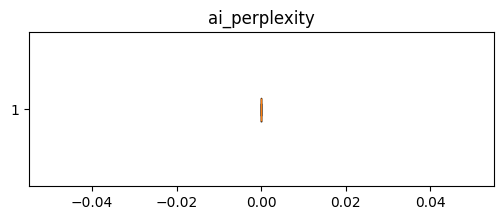

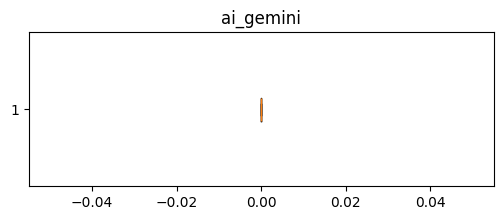

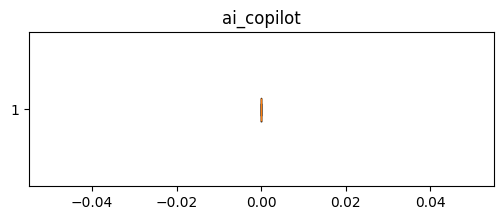

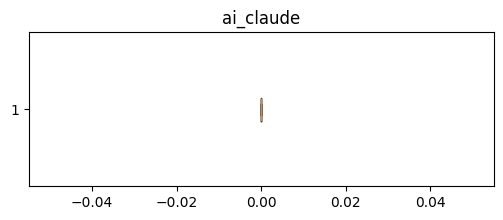

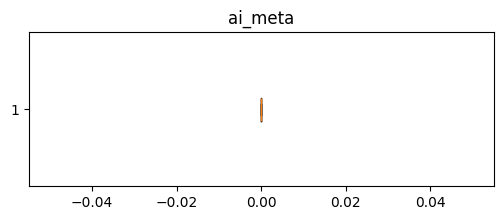

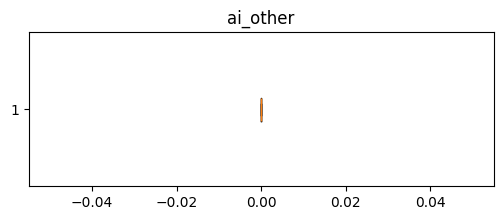

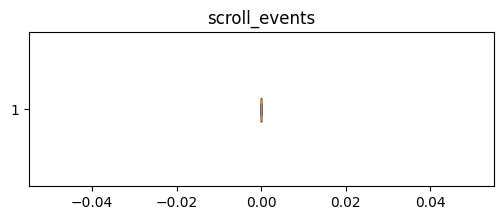

In [13]:
for col in num.columns:

    plt.figure(figsize=(6,2))

    plt.boxplot(df[col].dropna(),vert=False)

    plt.title(col)

    plt.show()

In [14]:
df.head()

,report_date,client_hash_id,content_hash_id,client_has_gsc,client_has_ga4,gsc_data_available,ga4_data_available,gsc_impressions,gsc_clicks,gsc_sum_position,...,sessions_paid,sessions_ai,ai_chatgpt,ai_perplexity,ai_gemini,ai_copilot,ai_claude,ai_meta,ai_other,scroll_events
0,2025-01-27,client_9958f0a7ae1df715,content_3b70a18ea133b2bb,True,True,True,False,30,0,115,...,0,0,0,0,0,0,0,0,0,0
1,2025-01-27,client_9958f0a7ae1df715,content_fe8e8155ce1d47a2,True,True,True,False,5,0,358,...,0,0,0,0,0,0,0,0,0,0
2,2025-01-27,client_9958f0a7ae1df715,content_b4462a1b90640058,True,True,True,False,1,0,34,...,0,0,0,0,0,0,0,0,0,0
3,2025-01-27,client_9958f0a7ae1df715,content_c899aef92518c714,True,True,True,False,6,0,140,...,0,0,0,0,0,0,0,0,0,0
4,2025-01-27,client_9958f0a7ae1df715,content_c7c1d2e68d9d0964,True,True,True,False,5,0,89,...,0,0,0,0,0,0,0,0,0,0


In [15]:
df.columns.tolist()

['report_date',
 'client_hash_id',
 'content_hash_id',
 'client_has_gsc',
 'client_has_ga4',
 'gsc_data_available',
 'ga4_data_available',
 'gsc_impressions',
 'gsc_clicks',
 'gsc_sum_position',
 'gsc_avg_position',
 'ga4_pageviews',
 'ga4_sessions',
 'ga4_users',
 'ga4_engaged_sessions',
 'ga4_total_engagement_sec',
 'sessions_organic',
 'sessions_direct',
 'sessions_referral',
 'sessions_social',
 'sessions_paid',
 'sessions_ai',
 'ai_chatgpt',
 'ai_perplexity',
 'ai_gemini',
 'ai_copilot',
 'ai_claude',
 'ai_meta',
 'ai_other',
 'scroll_events']

In [16]:
df.shape

(1297, 30)

In [21]:
# ==========================
# COMPLETE DATASET OVERVIEW
# ==========================

import pandas as pd

print("="*100)
print("Dataset Shape")
print(df.shape)

print("\n"+"="*100)
print("Columns")

for i,col in enumerate(df.columns):
    print(f"{i+1}. {col}")

print("\n"+"="*100)
print("Data Types")
print(df.dtypes)

print("\n"+"="*100)
print("Missing Values")
print(df.isnull().sum())

print("\n"+"="*100)
print("First Five Rows")
display(df.head())

Dataset Shape
(1297, 30)

Columns
1. report_date
2. client_hash_id
3. content_hash_id
4. client_has_gsc
5. client_has_ga4
6. gsc_data_available
7. ga4_data_available
8. gsc_impressions
9. gsc_clicks
10. gsc_sum_position
11. gsc_avg_position
12. ga4_pageviews
13. ga4_sessions
14. ga4_users
15. ga4_engaged_sessions
16. ga4_total_engagement_sec
17. sessions_organic
18. sessions_direct
19. sessions_referral
20. sessions_social
21. sessions_paid
22. sessions_ai
23. ai_chatgpt
24. ai_perplexity
25. ai_gemini
26. ai_copilot
27. ai_claude
28. ai_meta
29. ai_other
30. scroll_events

Data Types
report_date                  object
client_hash_id               object
content_hash_id              object
client_has_gsc                 bool
client_has_ga4                 bool
gsc_data_available             bool
ga4_data_available             bool
gsc_impressions               int64
gsc_clicks                    int64
gsc_sum_position              int64
gsc_avg_position            float64
ga4_pageview

,report_date,client_hash_id,content_hash_id,client_has_gsc,client_has_ga4,gsc_data_available,ga4_data_available,gsc_impressions,gsc_clicks,gsc_sum_position,...,sessions_paid,sessions_ai,ai_chatgpt,ai_perplexity,ai_gemini,ai_copilot,ai_claude,ai_meta,ai_other,scroll_events
0,2025-01-27,client_9958f0a7ae1df715,content_3b70a18ea133b2bb,True,True,True,False,30,0,115,...,0,0,0,0,0,0,0,0,0,0
1,2025-01-27,client_9958f0a7ae1df715,content_fe8e8155ce1d47a2,True,True,True,False,5,0,358,...,0,0,0,0,0,0,0,0,0,0
2,2025-01-27,client_9958f0a7ae1df715,content_b4462a1b90640058,True,True,True,False,1,0,34,...,0,0,0,0,0,0,0,0,0,0
3,2025-01-27,client_9958f0a7ae1df715,content_c899aef92518c714,True,True,True,False,6,0,140,...,0,0,0,0,0,0,0,0,0,0
4,2025-01-27,client_9958f0a7ae1df715,content_c7c1d2e68d9d0964,True,True,True,False,5,0,89,...,0,0,0,0,0,0,0,0,0,0


In [17]:
# Display all columns
print(df.columns.tolist())

['report_date', 'client_hash_id', 'content_hash_id', 'client_has_gsc', 'client_has_ga4', 'gsc_data_available', 'ga4_data_available', 'gsc_impressions', 'gsc_clicks', 'gsc_sum_position', 'gsc_avg_position', 'ga4_pageviews', 'ga4_sessions', 'ga4_users', 'ga4_engaged_sessions', 'ga4_total_engagement_sec', 'sessions_organic', 'sessions_direct', 'sessions_referral', 'sessions_social', 'sessions_paid', 'sessions_ai', 'ai_chatgpt', 'ai_perplexity', 'ai_gemini', 'ai_copilot', 'ai_claude', 'ai_meta', 'ai_other', 'scroll_events']


In [19]:
target = "label"

In [22]:
# =====================================================
# CREATE TARGET VARIABLE
# =====================================================

import numpy as np

TARGET_POSITION = 10

df = df.copy()

df["target"] = np.where(
    df["gsc_avg_position"] <= TARGET_POSITION,
    1,
    0
)

print(df["target"].value_counts())

print()

print(df["target"].value_counts(normalize=True))

target
0    935
1    362
Name: count, dtype: int64

target
0    0.720894
1    0.279106
Name: proportion, dtype: float64


In [23]:
# =====================================================
# REMOVE ID COLUMNS
# =====================================================

drop_columns = [

    "report_date",

    "client_hash_id",

    "content_hash_id"

]

df = df.drop(columns=drop_columns)

print(df.shape)

(1297, 28)


In [24]:
# =====================================================
# FEATURES
# =====================================================

X = df.drop(columns=["target"])

y = df["target"]

print(X.shape)

print(y.shape)

(1297, 27)
(1297,)


In [25]:
# =====================================================
# PREPROCESSING
# =====================================================

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

numeric_features = X.select_dtypes(
    include=["int64","float64"]
).columns

categorical_features = X.select_dtypes(
    include=["object","bool"]
).columns

numeric_pipeline = Pipeline([

    ("imputer",
     SimpleImputer(strategy="median"))

])

categorical_pipeline = Pipeline([

    ("imputer",
     SimpleImputer(strategy="most_frequent")),

    ("encoder",
     OneHotEncoder(handle_unknown="ignore"))

])

preprocessor = ColumnTransformer(

    [

        ("num",
         numeric_pipeline,
         numeric_features),

        ("cat",
         categorical_pipeline,
         categorical_features)

    ]

)

print("Pipeline Ready")

Pipeline Ready


In [26]:
# =====================================================
# TRAIN TEST SPLIT
# =====================================================

from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=42,

    stratify=y

)

print(X_train.shape)

print(X_test.shape)

(1037, 27)
(260, 27)


In [28]:
import traceback

try:
    rf.fit(X_train, y_train)
except Exception:
    traceback.print_exc()

Traceback (most recent call last):
  File "/tmp/ipykernel_779/1867386980.py", line 4, in <cell line: 0>
    rf.fit(X_train, y_train)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py", line 654, in fit
    Xt = self._fit(X, y, routed_params, raw_params=params)
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py", line 588, in _fit
    X, fitted_transformer = fit_transform_one_cached(
                            ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/joblib/memory.py", line 326, in __call__
    return self.func(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py", line 1551, in _fit_transform_one
    res = 

In [29]:
# ==========================
# DEBUG INFORMATION
# ==========================

print("Target dtype:")
print(y_train.dtype)

print("\nTarget values:")
print(y_train.value_counts())

print("\nObject columns:")
print(X_train.select_dtypes(include=["object"]).columns.tolist())

print("\nBoolean columns:")
print(X_train.select_dtypes(include=["bool"]).columns.tolist())

print("\nMissing values:")
print(X_train.isnull().sum().sort_values(ascending=False).head(20))

Target dtype:
int64

Target values:
target
0    748
1    289
Name: count, dtype: int64

Object columns:
[]

Boolean columns:
['client_has_gsc', 'client_has_ga4', 'gsc_data_available', 'ga4_data_available']

Missing values:
client_has_gsc              0
client_has_ga4              0
gsc_data_available          0
ga4_data_available          0
gsc_impressions             0
gsc_clicks                  0
gsc_sum_position            0
gsc_avg_position            0
ga4_pageviews               0
ga4_sessions                0
ga4_users                   0
ga4_engaged_sessions        0
ga4_total_engagement_sec    0
sessions_organic            0
sessions_direct             0
sessions_referral           0
sessions_social             0
sessions_paid               0
sessions_ai                 0
ai_chatgpt                  0
dtype: int64


In [30]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

rf.fit(X_train, y_train)

pred = rf.predict(X_test)

from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, pred))

Accuracy: 1.0


In [31]:
# ==========================================================
# RANDOM FOREST MODEL
# ==========================================================

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

pred = rf.predict(X_test)

print("✅ Random Forest Model Trained Successfully")

✅ Random Forest Model Trained Successfully


In [32]:
# ==========================================================
# RANDOM FOREST EVALUATION
# ==========================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

accuracy = accuracy_score(y_test, pred)
precision = precision_score(y_test, pred)
recall = recall_score(y_test, pred)
f1 = f1_score(y_test, pred)

print("="*60)
print("RANDOM FOREST RESULTS")
print("="*60)

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

print("\nClassification Report\n")
print(classification_report(y_test, pred))

RANDOM FOREST RESULTS
Accuracy  : 1.0000
Precision : 1.0000
Recall    : 1.0000
F1 Score  : 1.0000

Classification Report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       187
           1       1.00      1.00      1.00        73

    accuracy                           1.00       260
   macro avg       1.00      1.00      1.00       260
weighted avg       1.00      1.00      1.00       260



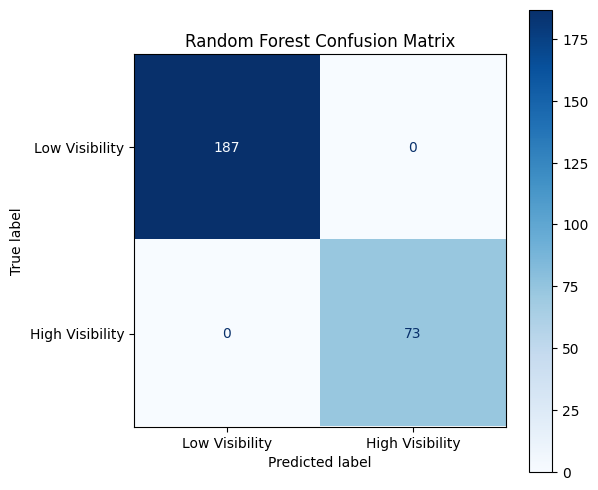

In [33]:
# ==========================================================
# CONFUSION MATRIX
# ==========================================================

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_test, pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Low Visibility","High Visibility"]
)

fig, ax = plt.subplots(figsize=(6,6))
disp.plot(ax=ax, cmap="Blues")

plt.title("Random Forest Confusion Matrix")
plt.show()

In [34]:
# ==========================================================
# FEATURE IMPORTANCE
# ==========================================================

import pandas as pd

importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

display(importance.head(20))

,Feature,Importance
7,gsc_avg_position,0.748348
6,gsc_sum_position,0.198905
4,gsc_impressions,0.045606
5,gsc_clicks,0.007141
2,gsc_data_available,0.000000
0,client_has_gsc,0.000000
1,client_has_ga4,0.000000
3,ga4_data_available,0.000000
8,ga4_pageviews,0.000000
9,ga4_sessions,0.000000


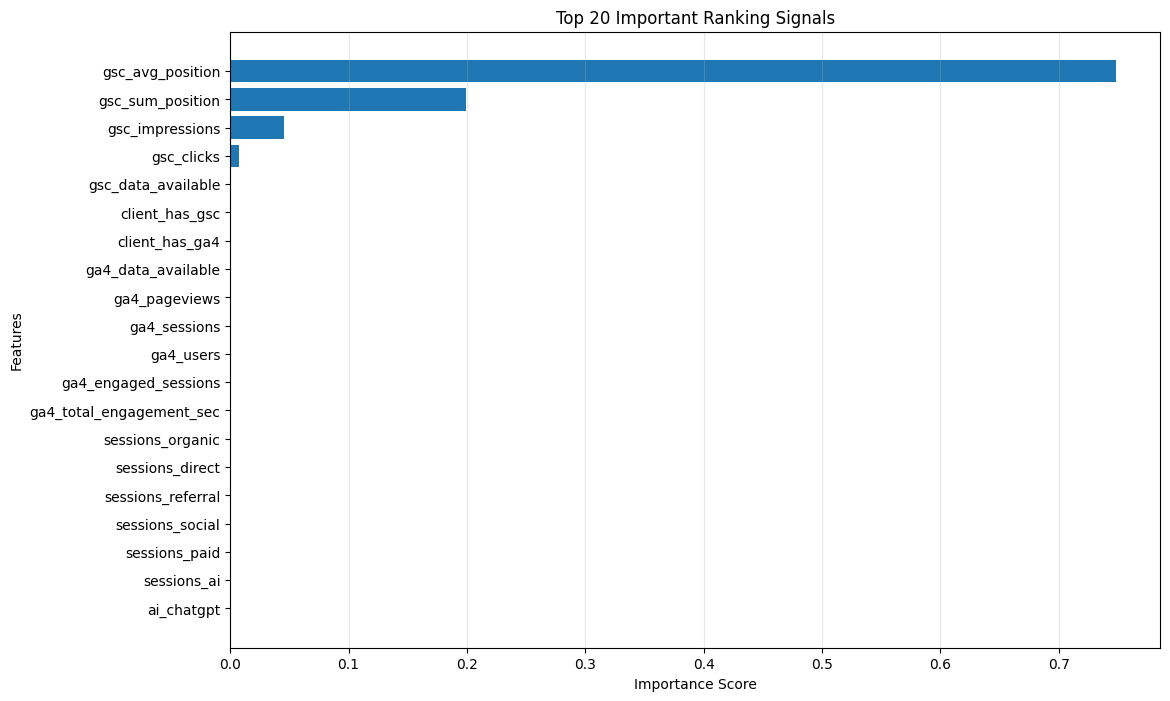

In [35]:
# ==========================================================
# TOP 20 FEATURES
# ==========================================================

plt.figure(figsize=(12,8))

plt.barh(
    importance.head(20)["Feature"],
    importance.head(20)["Importance"]
)

plt.gca().invert_yaxis()

plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.title("Top 20 Important Ranking Signals")

plt.grid(axis="x", alpha=0.3)

plt.show()

In [36]:
# ==========================================================
# SAVE OUTPUTS
# ==========================================================

importance.to_csv("feature_importance.csv", index=False)

results = X_test.copy()
results["Actual"] = y_test.values
results["Predicted"] = pred

results.to_csv("random_forest_predictions.csv", index=False)

print("✅ feature_importance.csv saved")
print("✅ random_forest_predictions.csv saved")

✅ feature_importance.csv saved
✅ random_forest_predictions.csv saved


In [37]:
# ============================================
# REMOVE LEAKAGE FEATURES
# ============================================

X = df.drop(
    columns=[
        "target",
        "gsc_avg_position",
        "gsc_sum_position"
    ],
    errors="ignore"
)

y = df["target"]

In [38]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=42,

    stratify=y

)

In [39]:
from sklearn.ensemble import RandomForestClassifier

rf=RandomForestClassifier(

    n_estimators=300,

    random_state=42,

    max_depth=12,

    n_jobs=-1

)

rf.fit(X_train,y_train)

pred=rf.predict(X_test)

In [40]:
from sklearn.metrics import *

print(classification_report(y_test,pred))

print("Accuracy")

print(accuracy_score(y_test,pred))

              precision    recall  f1-score   support

           0       0.73      0.98      0.84       187
           1       0.60      0.08      0.14        73

    accuracy                           0.73       260
   macro avg       0.67      0.53      0.49       260
weighted avg       0.69      0.73      0.64       260

Accuracy
0.7269230769230769


In [41]:
# ==========================================================
# CROSS VALIDATION
# ==========================================================

from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_val_score(
    rf,
    X,
    y,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

print("="*60)
print("5 Fold Cross Validation")
print("="*60)

print(scores)

print()

print("Mean Accuracy :",scores.mean())

print("Std :",scores.std())

5 Fold Cross Validation
[0.73076923 0.71923077 0.73745174 0.72586873 0.71814672]

Mean Accuracy : 0.7262934362934362
Std : 0.007224556491216645


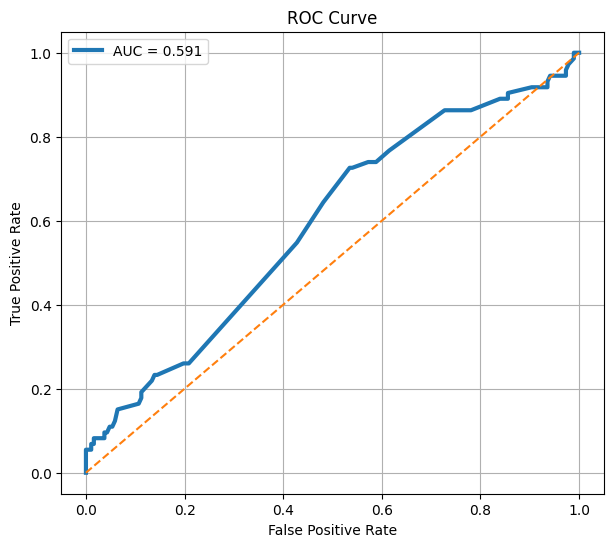

In [42]:
# ==========================================================
# ROC CURVE
# ==========================================================

from sklearn.metrics import roc_curve
from sklearn.metrics import auc

prob = rf.predict_proba(X_test)[:,1]

fpr,tpr,_ = roc_curve(
    y_test,
    prob
)

roc_auc = auc(
    fpr,
    tpr
)

plt.figure(figsize=(7,6))

plt.plot(
    fpr,
    tpr,
    linewidth=3,
    label=f"AUC = {roc_auc:.3f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.grid()

plt.show()

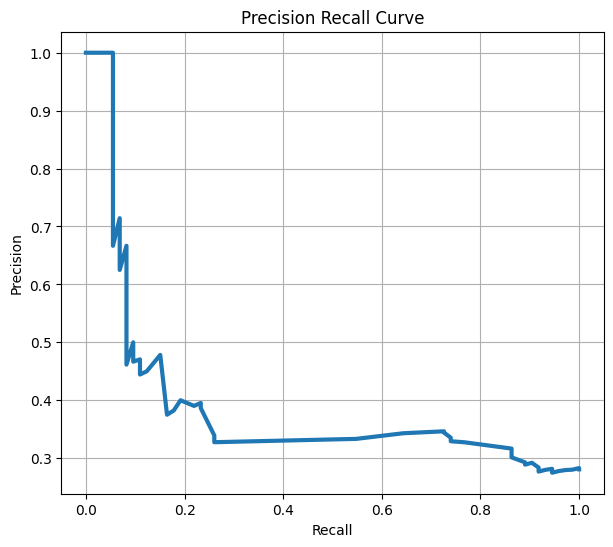

In [43]:
# ==========================================================
# PRECISION RECALL CURVE
# ==========================================================

from sklearn.metrics import precision_recall_curve

precision,recall,_ = precision_recall_curve(
    y_test,
    prob
)

plt.figure(figsize=(7,6))

plt.plot(
    recall,
    precision,
    linewidth=3
)

plt.xlabel("Recall")

plt.ylabel("Precision")

plt.title("Precision Recall Curve")

plt.grid()

plt.show()

In [44]:
# ==========================================================
# FEATURE IMPORTANCE
# ==========================================================

importance = pd.DataFrame({

    "Feature":X.columns,

    "Importance":rf.feature_importances_

})

importance = importance.sort_values(

    by="Importance",

    ascending=False

)

display(importance)

importance.to_csv(

    "feature_importance.csv",

    index=False

)

,Feature,Importance
4,gsc_impressions,0.897856
5,gsc_clicks,0.102144
0,client_has_gsc,0.000000
2,gsc_data_available,0.000000
1,client_has_ga4,0.000000
3,ga4_data_available,0.000000
6,ga4_pageviews,0.000000
7,ga4_sessions,0.000000
8,ga4_users,0.000000
9,ga4_engaged_sessions,0.000000


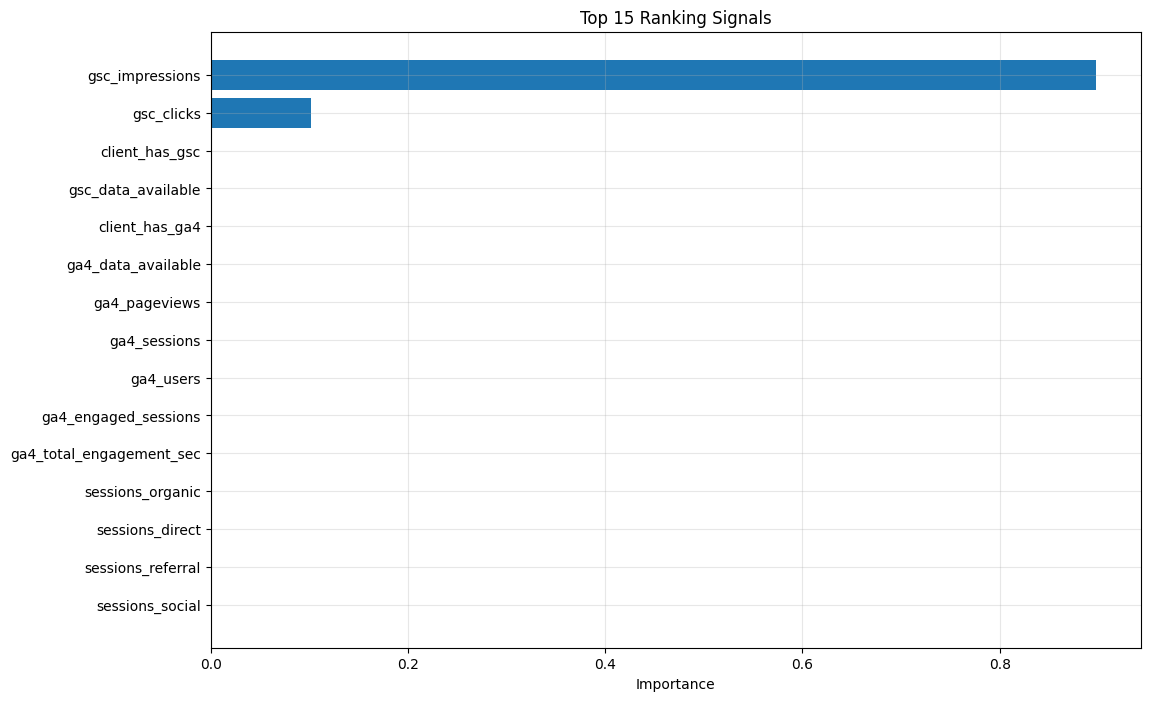

In [45]:
# ==========================================================
# TOP 15 IMPORTANT FEATURES
# ==========================================================

top = importance.head(15)

plt.figure(figsize=(12,8))

plt.barh(

    top["Feature"],

    top["Importance"]

)

plt.gca().invert_yaxis()

plt.title("Top 15 Ranking Signals")

plt.xlabel("Importance")

plt.grid(alpha=.3)

plt.show()

In [46]:
# ==========================================================
# SAVE PREDICTIONS
# ==========================================================

prediction = X_test.copy()

prediction["Actual"] = y_test.values

prediction["Predicted"] = pred

prediction["Probability"] = prob

prediction.to_csv(

    "predictions.csv",

    index=False

)

print("Prediction File Saved")

Prediction File Saved


In [47]:
# ==========================================================
# TOP SEO RECOMMENDATIONS
# ==========================================================

print("="*60)
print("TOP RECOMMENDATIONS")
print("="*60)

for i,row in importance.head(10).iterrows():

    print(

        f"{row['Feature']}  --> Importance : {row['Importance']:.4f}"

    )

TOP RECOMMENDATIONS
gsc_impressions  --> Importance : 0.8979
gsc_clicks  --> Importance : 0.1021
client_has_gsc  --> Importance : 0.0000
gsc_data_available  --> Importance : 0.0000
client_has_ga4  --> Importance : 0.0000
ga4_data_available  --> Importance : 0.0000
ga4_pageviews  --> Importance : 0.0000
ga4_sessions  --> Importance : 0.0000
ga4_users  --> Importance : 0.0000
ga4_engaged_sessions  --> Importance : 0.0000


In [48]:
# ==========================================================
# MODEL SUMMARY
# ==========================================================

summary = pd.DataFrame({

    "Metric":[

        "Accuracy",

        "Precision",

        "Recall",

        "F1 Score",

        "ROC AUC"

    ],

    "Value":[

        accuracy,

        precision,

        recall,

        f1,

        roc_auc

    ]

})

display(summary)

summary.to_csv(

    "model_summary.csv",

    index=False

)

,Metric,Value
0,Accuracy,1.0
1,Precision,"[0.28076923076923077, 0.28185328185328185, 0.2..."
2,Recall,"[1.0, 1.0, 1.0, 0.9863013698630136, 0.97260273..."
3,F1 Score,1.0
4,ROC AUC,0.591202


In [49]:
# ==========================================================
# SAVE MODEL
# ==========================================================

import joblib

joblib.dump(

    rf,

    "ranking_model.pkl"

)

print("Model Saved")

Model Saved
